In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['figure.figsize'] = 12,6
plt.rcParams['font.size'] = 14
plt.rcParams['axes.unicode_minus'] = False

# 데이터 전처리 관련 ####################################################
# 결측치 처리
from sklearn.impute import SimpleImputer
# 표준화
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
# 인코더
from sklearn.preprocessing import LabelEncoder

# 학습 모델 성능 관련 ####################################################
# 원하는 비율로 데이터를 나누기 위해
from sklearn.model_selection import train_test_split
# K-Fold 교차 검증
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
# 학습곡
from sklearn.model_selection import learning_curve

# 모델 성능평가 #############################################
# 회귀용
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error
# 분류용
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.metrics import roc_auc_score

### 과대적합, 과소적합, 일반화 테스트

In [6]:
# 가상의 비선형 데이터를 생성한다.
def true_fun(X) :
    return np.cos(1.5 * np.pi * X)

np.random.seed(0)
n_samples = 30
X = np.sort(np.random.rand(n_samples))
y = true_fun(X) + np.random.randn(n_samples) * 0.1

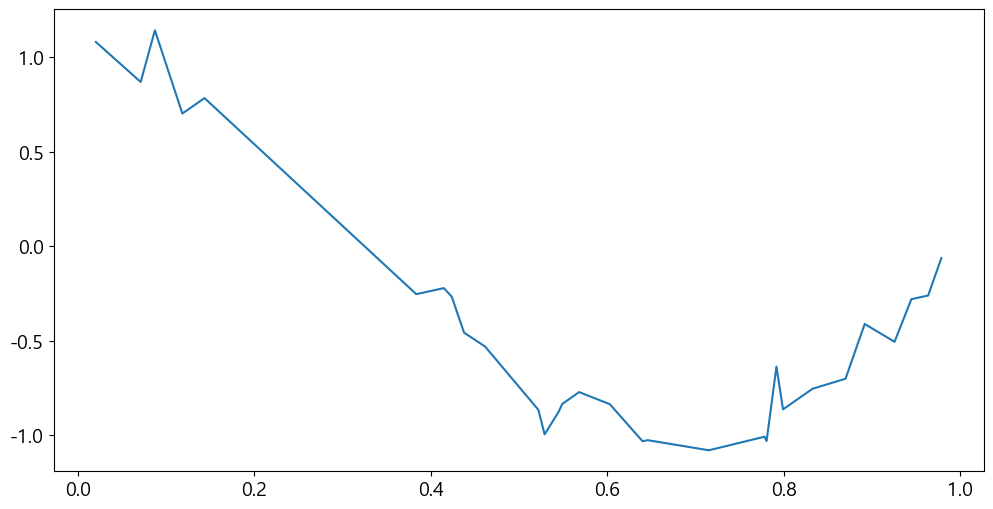

In [7]:
plt.plot(X,y)
plt.show()

In [8]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

[[0.0202184 ]
 [0.07103606]
 [0.0871293 ]
 [0.11827443]
 [0.14335329]
 [0.38344152]
 [0.41466194]
 [0.4236548 ]
 [0.43758721]
 [0.46147936]
 [0.52184832]
 [0.52889492]
 [0.54488318]
 [0.5488135 ]
 [0.56804456]
 [0.60276338]
 [0.63992102]
 [0.64589411]
 [0.71518937]
 [0.77815675]
 [0.78052918]
 [0.79172504]
 [0.79915856]
 [0.83261985]
 [0.87001215]
 [0.891773  ]
 [0.92559664]
 [0.94466892]
 [0.96366276]
 [0.97861834]]
[[2.02183974e-02 4.08783595e-04 8.26494919e-06 1.67104028e-07]
 [7.10360582e-02 5.04612156e-03 3.58456585e-04 2.54633428e-05]
 [8.71292997e-02 7.59151487e-03 6.61443374e-04 5.76310980e-05]
 [1.18274426e-01 1.39888398e-02 1.65452200e-03 1.95687639e-04]
 [1.43353287e-01 2.05501650e-02 2.94593371e-03 4.22309282e-04]
 [3.83441519e-01 1.47027398e-01 5.63764089e-02 2.16170559e-02]
 [4.14661940e-01 1.71944524e-01 7.12988501e-02 2.95649195e-02]
 [4.23654799e-01 1.79483389e-01 7.60389992e-02 3.22142869e-02]
 [4.37587211e-01 1.91482567e-01 8.37903227e-02 3.66655736e-02]
 [4.61479362

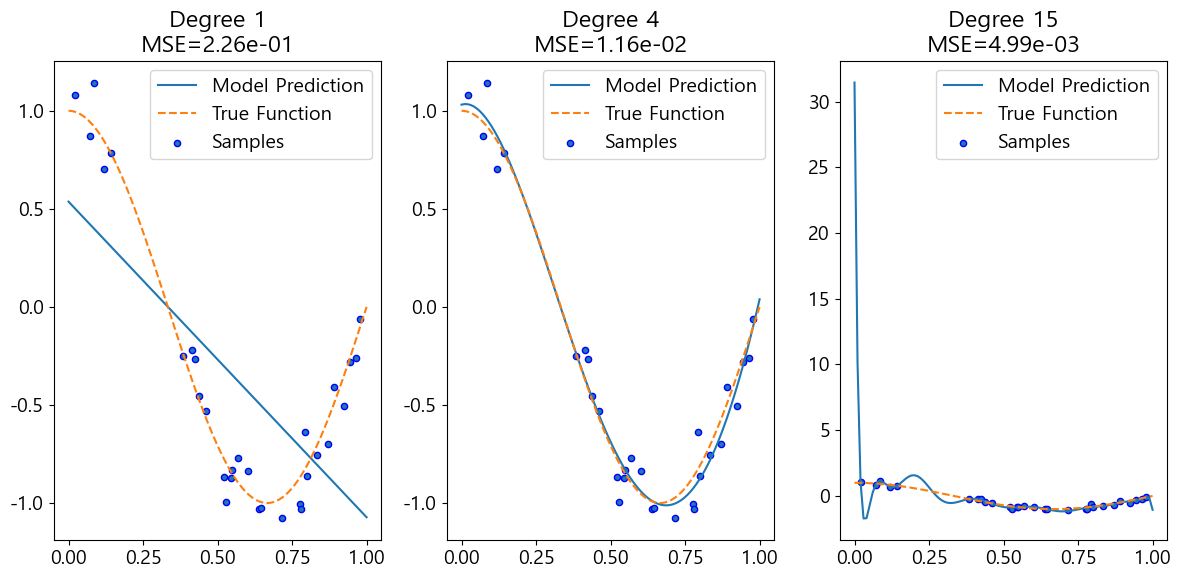

In [20]:
# 차수 (Degree) 설정
degrees = [1,4,15]

for i, degree in enumerate(degrees) :
    plt.subplot(1,3,i+1)

    # 데이터를 변환 (차원 확장)
    # PolynomialFeatures 객체 생성
    # degree : 어디까지 제곱을 할 것인가? (3이면 x, x^2, x^3)
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    # 데이터를 발생시킨다.
    X_poly = poly.fit_transform(X.reshape(-1,1))
    print(X_poly)

    # 모델 학습
    model = LinearRegression()
    model.fit(X_poly, y)

    # 시각화 데이터를 준비
    X_test = np.linspace(0,1,100).reshape(-1,1)
    X_test_poly = poly.transform(X_test)
    y_pred = model.predict(X_test_poly)

    # 시각화
    plt.plot(X_test, y_pred, label='Model Prediction')
    plt.plot(X_test, true_fun(X_test), label = 'True Function', linestyle='--')
    plt.scatter(X,y, edgecolors='b', s=20, label='Samples')

    # MSE
    mse = mean_squared_error(y, model.predict(X_poly))
    plt.title(f'Degree {degree}\nMSE={mse:.2e}')
    plt.legend()

plt.tight_layout()
plt.show()

### 학습 곡선

In [22]:
from sklearn.svm import SVC
from sklearn.datasets import load_digits

In [23]:
digits = load_digits()
X = digits.data
y = digits.target

In [24]:
# 학습모델
model = SVC(gamma=0.001)

In [27]:
# 학습 곡선 데이터 계산
# learning_curve 함수는 훈련 데이터 양을 늘려가면서 반복 학습하여 '데이터의 양과 성능'의 관계를 측정한다.
# 데이터의 양이 많아 질 때 지속적으로 상승하면 데이터를 더 추가하면 성능이 좋아진다는 것을 확인할 수 있다.
train_sizes, train_scores, test_scores = learning_curve(
    # n_jobs=-1 병렬처리로 커터 최대성능끌어낸다. np.linspace(0.1,1.0,5) 0.1~1까지 5개로 나눠서 한다
    model, X, y, cv=5, n_jobs=-1, train_sizes = np.linspace(0.1,1.0,5) 
)

In [28]:
# 성능 결과값을 평균을 구한다
train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

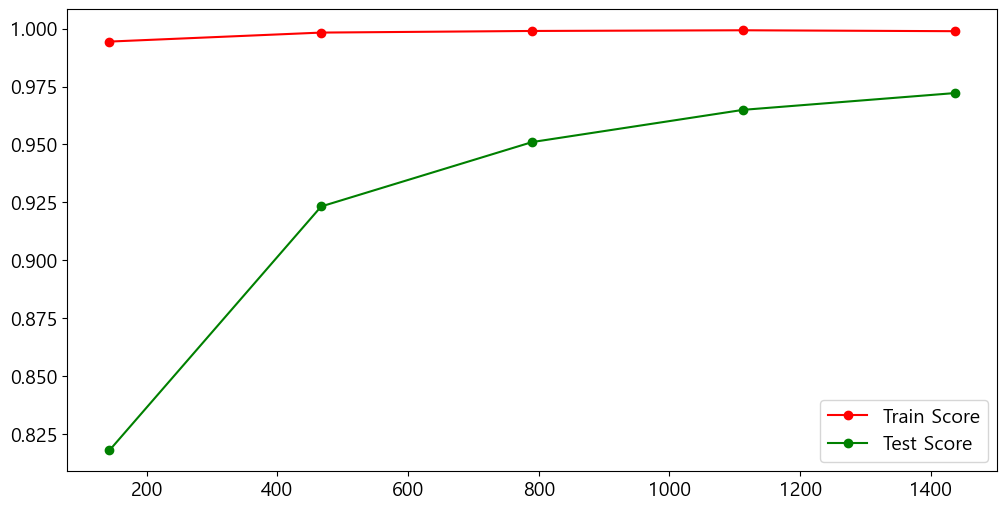

In [34]:
# 훈련 데이터 점수 시각화(빨간색)
plt.plot(train_sizes, train_scores_mean, 'o-', color='red', label='Train Score')
# 검증 데이터 점수 시각화(초록색)
plt.plot(train_sizes, test_scores_mean, 'o-', color='g', label='Test Score')
plt.legend()
plt.show()

- 학습데이터의 선이 높게 나타나고 테스트 데이터의 선이 점점 상승하며 학습 데이터의 선과 맞닿을려고 하는 것이 일반화가 되고 있는 상황이다.
- 만약 특정 시점 이후로 테스트 데이터의 선이 하강하기 시작하면 과대적합이 발생하기 시작한 것이다.
- 학습 데이터의 선과 테스트 데이터의 선이 모두 낮게 되어 있으면 과소적합이 발생한 것이다.